In [116]:
# import stuff

import numpy as np 
import matplotlib.pyplot as plt 
import math

# 1 a)

In [105]:
# Oppg 1 a

# Interpolation
def lagrange_interpolation_array(x_nodes, y_nodes, x_values):
    if len(x_nodes) != len(y_nodes):
        raise IndexError("Size of x_nodes and y_nodes should be the same")
    
    n = len(x_nodes) - 1

    def q_i(x, x_nodes, i):
        if i < 0 or i > n:
            raise IndexError("Indexen er utanfor node-talet")

        q = 1
        for nr in range(len(x_nodes)):
            if nr == int(i):
                continue
            q *= x - x_nodes[nr]
        return q

    y_values = []
    for x in x_values:

        y_values.append(sum([y_nodes[nr] * q_i(x, x_nodes, nr)/(q_i(x_nodes[nr], x_nodes, nr)) for nr in range(len(x_nodes))]))
    return y_values


def construct_p_n_function(x_nodes, y_nodes):
    return lambda x: lagrange_interpolation_array(x_nodes, y_nodes, x)


# Nodes:
def equidistant_nodes(node_count = 50):
    return np.linspace(-1, 1, node_count)

def chubychub_nodes(node_count = 50):
    count_nr = np.arange(0, node_count)
    return np.cos(((count_nr+1/2)*np.pi)/(node_count))

def rescale(nodes, start, end):
    return (end-start)/2 * nodes + (end+start)/2

In [106]:
# Pritty display




def display_interpolation(x_node_func, func, x_node_interval=(-1, 1), node_count=15, label=None, show_nodes=False):


    x_nodes = x_node_func(node_count)
    x_nodes = rescale(x_nodes, x_node_interval[0], x_node_interval[-1])
    y_nodes = func(x_nodes)

    x_vals = np.linspace(x_nodes[0], x_nodes[-1], 1000)
    y_interpolation_vals = lagrange_interpolation_array(x_nodes, y_nodes, x_vals)

    plt.plot(x_vals, y_interpolation_vals, label=label)
    plt.xlabel("x")
    plt.ylabel("p_n(x)")
    if show_nodes:
        plt.scatter(x_nodes, y_nodes, label=label)



def display_interpolation_error(x_node_func, func, x_node_interval=(-1, 1), node_count=15, label=None):

    x_nodes = x_node_func(node_count)
    x_nodes = rescale(x_nodes, x_node_interval[0], x_node_interval[1])
    y_nodes = func(x_nodes)

    x_vals = np.linspace(x_node_interval[0], x_node_interval[1], 1000)
    y_interpolation = lagrange_interpolation_array(x_nodes, y_nodes, x_vals)

    y_true = func(x_vals)

    error = np.abs(y_true - y_interpolation)

    plt.plot(x_vals, error, label=label)
    plt.xlabel("x")
    plt.ylabel("error: |f(x) - p_n(x)|")
    return np.max(error)



def finish_display():
    plt.legend()
    plt.grid()
    plt.show()

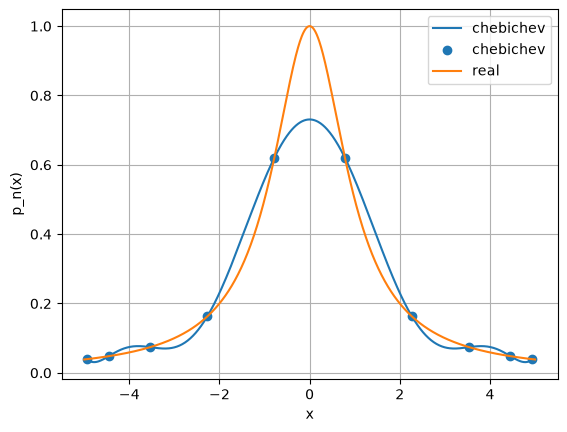

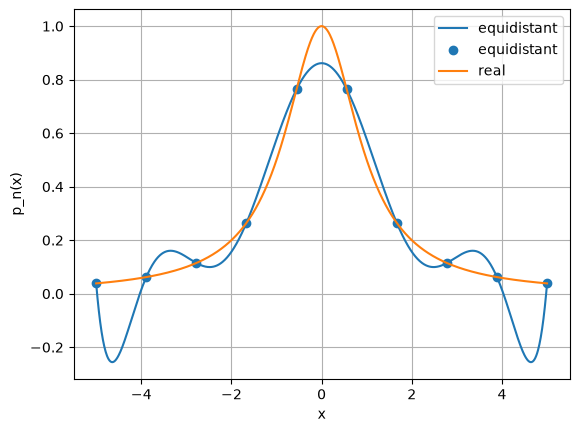

In [107]:

def runge_func(x_nodes):
    return 1/(x_nodes**2+1)



# plotting mr runge for 10 nodes
display_interpolation(chubychub_nodes, runge_func, (-5, 5), label="chebichev", node_count=10, show_nodes=True)
plt.plot(np.linspace(-5, 5, 1000), runge_func(np.linspace(-5, 5, 1000)), label="real")
finish_display()
display_interpolation(equidistant_nodes, runge_func, (-5, 5), label="equidistant", node_count=10, show_nodes=True)
plt.plot(np.linspace(-5, 5, 1000), runge_func(np.linspace(-5, 5, 1000)), label="real")
finish_display()



## Prediction time

For the same x span, but for 15, 20, 30 i predict that the equidistant nodes wil fluctuate more towards the edges and doesnt converge, because for one thing it is apparent that it does above (with equidistant nodes) but also because in the lecture we found that a condition for uniform convergence is that $\lim\limits_{n \to \infty} \frac{M_{n+1}}{(n+1)!} \max\limits_{x \in [a, b]}|\Pi _{n+1}(x)| = 0$. Here $M_i$ is the upper bound of the $i$'th derivative of the function and $\Pi$ is the product of all $(x-x_i)$. For $f(x) = \frac{1}{1+x^2}$ this does not equal 0 for equidistant nodes, however it does for chebychev nodes. 

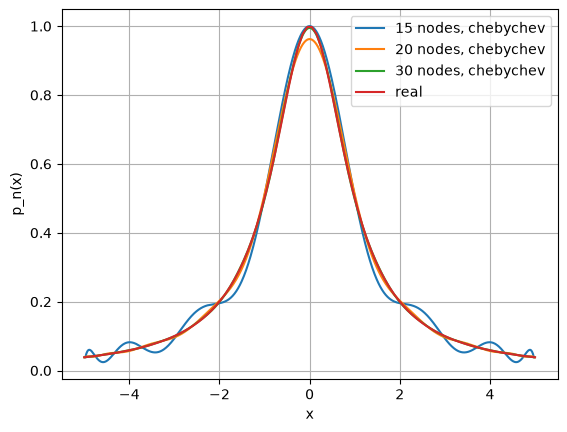

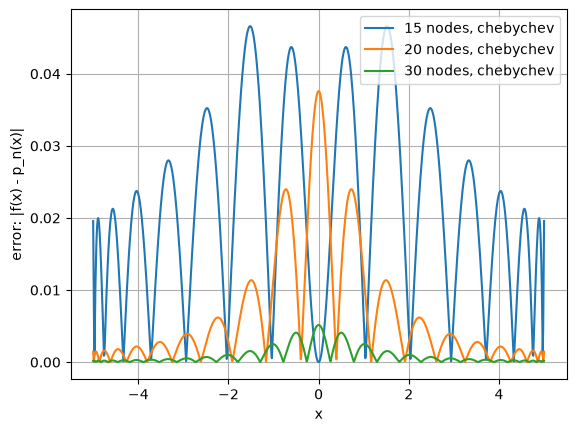

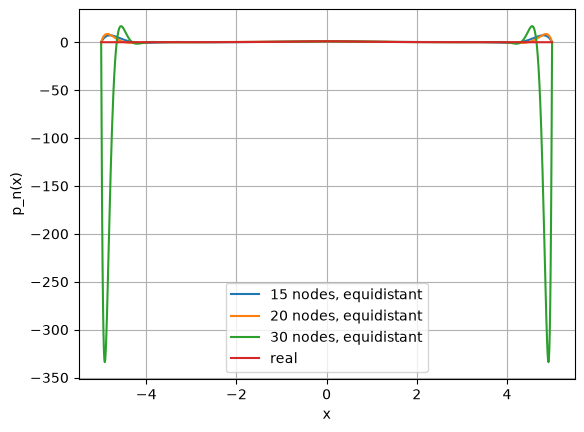

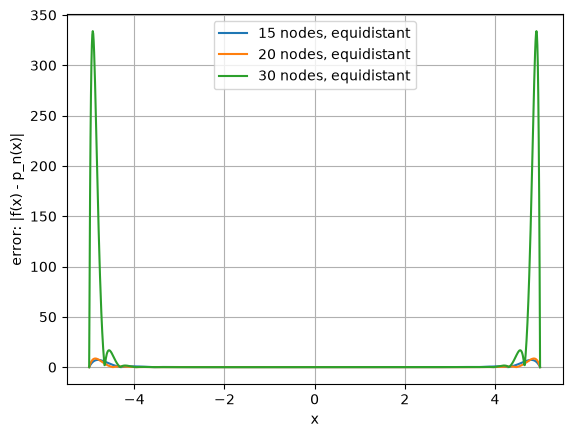

In [108]:

# Cheby
for n in [15, 20, 30]:
    display_interpolation(chubychub_nodes, runge_func, (-5, 5), node_count=n, show_nodes=False, label=f"{n} nodes, chebychev")
plt.plot(np.linspace(-5, 5, 100), runge_func(np.linspace(-5, 5, 100)), label="real")
finish_display()


# Cheby error
for n in [15, 20, 30]:
    display_interpolation_error(chubychub_nodes, runge_func, (-5, 5), node_count=n, label=f"{n} nodes, chebychev")
finish_display()



# equi
for n in [15, 20, 30]:
    display_interpolation(equidistant_nodes, runge_func, (-5, 5), node_count=n, show_nodes=False, label=f"{n} nodes, equidistant")
plt.plot(np.linspace(-5, 5, 100), runge_func(np.linspace(-5, 5, 100)), label="real")
finish_display()


# Equi error
for n in [15, 20, 30]:
    display_interpolation_error(equidistant_nodes, runge_func, (-5, 5), node_count=n, label=f"{n} nodes, equidistant")
finish_display()



### Outcome vs prediction

You can see that there was much more occilation in the equidistant nodes as supposed to chebychev nodes. When we look at the error we see that for chebychev nodes, the error decrese for biger node count and it's somewhat evenly spaced however for the equidistant nodes, the error is bigger the more nodes there are, and it is biggest at the edges, where it occilates most.

### Predcition for $x \in [-1, 1]$

Considering this looks ore like a polynomial function i am guessing the error wil be smaller, but as chebychev nodes has the optimal node separation for separation, i am guessing that will stil have a smaller error. I am also guessing that the error wil be about equaly distributed along x in chebychev nodes, while being bigger at the edges for the equidistant ones. I am also guessing the overall error will become bigger the more nodes there are for equidistant nodes and smaller for chebichev nodes, reason being that the error diverges for equidistant nodes and converges to 0 for chebichev, and that is the trend from before. 

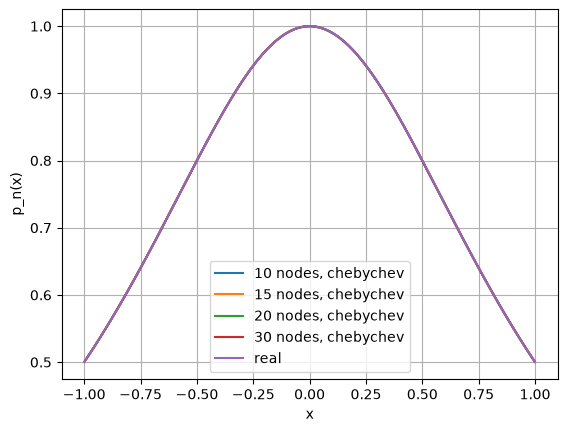

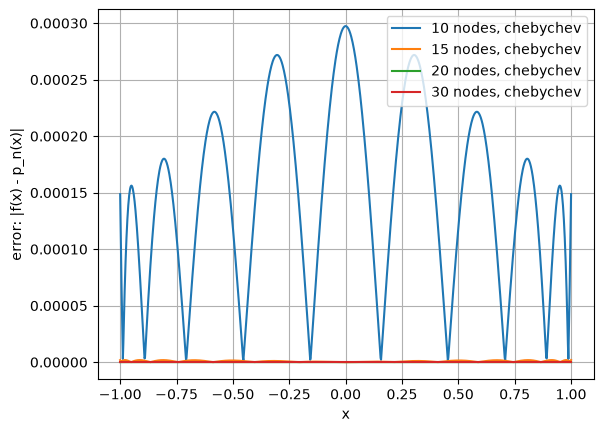

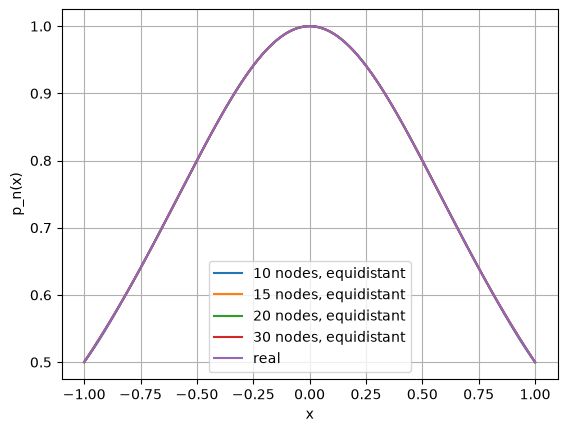

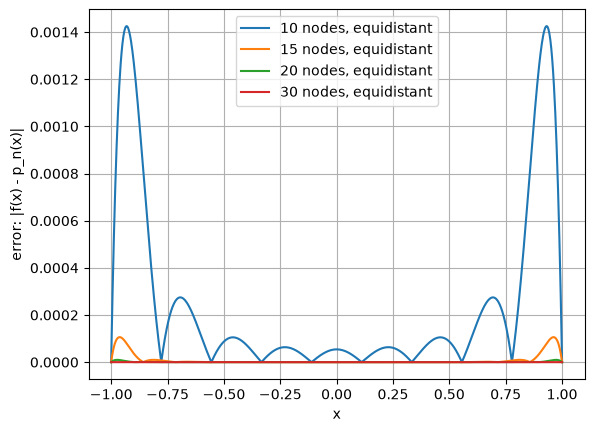

In [109]:
# Now for the interval [-1, 1]


# Cheby
for n in [10, 15, 20, 30]:
    display_interpolation(chubychub_nodes, runge_func, (-1, 1), node_count=n, show_nodes=False, label=f"{n} nodes, chebychev")
plt.plot(np.linspace(-1, 1, 100), runge_func(np.linspace(-1, 1, 100)), label="real")
finish_display()


# Cheby error
for n in [10, 15, 20, 30]:
    display_interpolation_error(chubychub_nodes, runge_func, (-1, 1), node_count=n, label=f"{n} nodes, chebychev")
finish_display()



# equi
for n in [10, 15, 20, 30]:
    display_interpolation(equidistant_nodes, runge_func, (-1, 1), node_count=n, show_nodes=False, label=f"{n} nodes, equidistant")
plt.plot(np.linspace(-1, 1, 100), runge_func(np.linspace(-1, 1, 100)), label="real")
finish_display()


# Equi error
for n in [10, 15, 20, 30]:
    display_interpolation_error(equidistant_nodes, runge_func, (-1, 1), node_count=n, label=f"{n} nodes, equidistant")
finish_display()

## Comment of error

The error is now much smaller as expected. For chebichev nodes the error is biger towards the center something i had not predicted, but the equdistant error is indeed bigger towards the edges. For some reason, the error for equidistant nodes doesn't diverge the more nodes i have for that interval, which is against my prediction.

# 1 b)

Why does both two- and max-norm converge for the functions $f_1(x) = \cos(2\pi x)$ and $f_2(x) = e^{3x}\sin(2x)$, for both chebychev and equidistant nodes, as the nodecount increses? If we find that the interpolation converge, with this condition (mentioned earlier) $\lim\limits_{n \to \infty} \frac{M_{n+1}}{(n+1)!} \max\limits_{x \in [a, b]}|\Pi _{n+1}(x)| = 0$, we know that the two- and max-norm will also converge towards the norm of the function over which we interpolate. That is because this condition is an upper bound of the max-norm of the error between the function and its interpolation polynomial. Mathematicaly we can say: $$\lim\limits_{n \to \infty}\frac{M_{n+1}}{(n+1)!}\max\limits_{x\in[a,b]}|\Pi_{n+1}(x)| = 0 \implies \|f-p_n\|_\infty \to 0, \|f-p_n\|_2 \to 0 \implies \|p_n\|_\infty \to \|f\|_\infty,\ \|p_n\|_2 \to \|f\|_2$$

First, differentiating over $f_1(x)$ we get that $\max(|f_1^{(n+1)}(x)|) = (2 \pi)^{n+1}$, so $\boxed{M_{n+1} = (2 \pi)^{n+1}}$ is an upper bound for $f_1^{(n+1)}(x)$. Differentiating over $f_2(x)$ gives $f_2^{(n+1)}(x) = \frac{d^{n+1}}{dx^{n+1}} (Im(e^{(3+2i)x})) = Im(\frac{d^{n+1}}{dx^{n+1}}(e^{(3+2i)x})) = Im((3+2i)^{n+1}e^{(3+2i)x})$, so $|f_2^{(n+1)}(x)| \leq |(3+2i)^{n+1}e^{(3+2i)x}| \leq (\sqrt{3^2 + 2^2})^{n+1}e^{3x} = 13^{\frac{n+1}{2}}e^{3x}$. Considering $x \in [0, \frac{\pi}{4}]$, we can set $\boxed{M_{n+1} = 13^{\frac{n+1}{2}}e^{\frac{3 \pi}{4}}}$ as an upper bound for $f_2^{(n+1)}(x)$.

For this part, $\max\limits_{x \in [a, b]}|\Pi _{n+1}(x)|$, we know that the biggest interval we are looking at is $x \in [0, 1]$ for $f_1$ and $x \in [0, \frac{\pi}{4}]$ for $f_2$, so $|x-x_i| \leq |1-0| = 1$ for both functions. For all the nodes we get $\boxed{\max\limits_{x \in [a, b]}|\Pi _{n+1}(x)| \leq 1^{n+1} = 1}$. For a tighter upper bound for $f_2(x)$ we can similarly derive $\boxed{\max\limits_{x \in [a, b]}|\Pi _{n+1}(x)| \leq (\frac{\pi}{4})^{n+1}}$

Combining this we get $\lim\limits_{n \to \infty} \frac{M_{n+1}}{(n+1)!} \max\limits_{x \in [0, 1]}|\Pi _{n+1}(x)| \leq \lim\limits_{n \to \infty} \frac{(2 \pi)^{n+1}}{(n+1)!}$ for $f_1(x)$ and $\lim\limits_{n \to \infty} \frac{M_{n+1}}{(n+1)!} \max\limits_{x \in [0, \frac{\pi}{4}]}|\Pi _{n+1}(x)| \leq \lim\limits_{n \to \infty} \frac{13^{\frac{n+1}{2}}e^{\frac{3 \pi}{4}} (\frac{\pi}{4})^{n+1}}{(n+1)!}$ for $f_2(x)$. We know that as $n \to \infty$, factorials grow faster than exponentials, so both goes to 0. $\boxed{\lim\limits_{n\to\infty}\|f-p_n\|_\infty = \lim\limits_{n \to \infty}\|f-p_n\|_2 = 0}$ 

In [121]:
def norm_max(f, x_values):
    return np.max(np.abs(f(x_values)))

def norm_2(f, x_values):
    return np.sqrt(x_values[-1]-x_values[0])/np.sqrt(len(x_values)) * np.sqrt(np.sum(f(x_values)**2))


def interpolation_error_norm(f, p_n, norm, x_values):
    diff = lambda x: f(x) - p_n(x)
    return norm(diff, x_values)





def error_norm_from_nodes(f, x_nodes, norm, x_count):

    p_n = construct_p_n_function(x_nodes, f(x_nodes))

    x_values = np.linspace(np.min(x_nodes), np.max(x_nodes), x_count)


    return interpolation_error_norm(f, p_n, norm, x_values)


def upper_bound_analy_error_f_1(n):
    return (2*np.pi)**(n+1)/(math.factorial(n+1))
def upper_bound_analy_error_f_2(n):
    return 13**((n+1)/2) * np.exp(3*np.pi/4) * (np.pi/4)**(n+1)/(math.factorial(n+1))


def diaplay_analy_upper_error(bounded_func, node_counts, label=None):
    error = np.array([bounded_func(int(n)) for n in node_counts])
    plt.plot(node_counts, error, label=label)



def display_error_norms(f, x_interval, node_type, norm, node_counts, label=None):
    error_norms = []
    for n in node_counts:
        x_nodes = rescale(node_type(n), x_interval[0], x_interval[-1])

        e_norm = error_norm_from_nodes(f, x_nodes, norm, 1000)
        error_norms.append(e_norm)
    plt.plot(node_counts, error_norms, label=label)
    plt.xlabel("node count")
    plt.ylabel("error norm, $||f(x) - p_n(x)||$")

    


In [111]:
#function_defenitions

def f_1_b(x):
    return np.cos(2*np.pi * x)

def f_2_b(x):
    return np.exp(3*x) * np.sin(2*x)



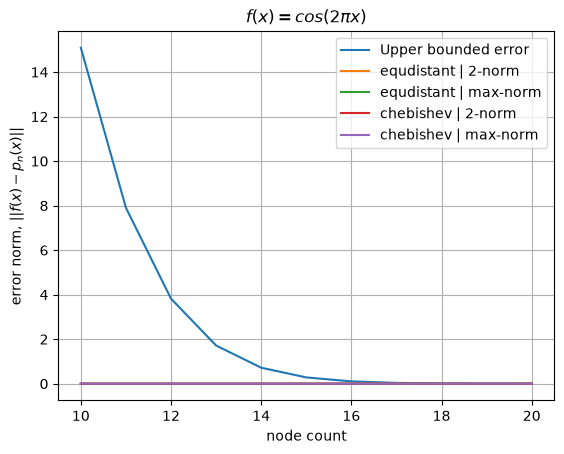

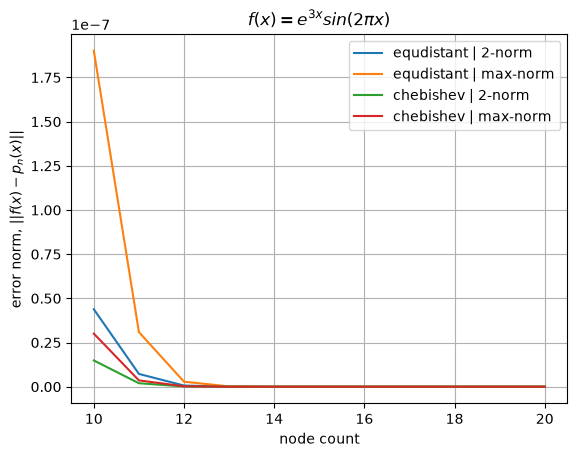

In [129]:
# display:

node_counts = np.array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20])
plt.title(r"$f(x) = cos(2 \pi x)$")
diaplay_analy_upper_error(upper_bound_analy_error_f_1, node_counts, label="Upper bounded error")
display_error_norms(f_1_b, (0, 1), equidistant_nodes, norm_2, node_counts, label="equdistant | 2-norm")
display_error_norms(f_1_b, (0, 1), equidistant_nodes, norm_max, node_counts, label="equdistant | max-norm")
display_error_norms(f_1_b, (0, 1), chubychub_nodes, norm_2, node_counts, label="chebishev | 2-norm")
display_error_norms(f_1_b, (0, 1), chubychub_nodes, norm_max, node_counts, label="chebishev | max-norm")
finish_display()

plt.title(r"$f(x) = e^{3x}sin(2 \pi x)$")
# diaplay_analy_upper_error(upper_bound_analy_error_f_2, node_counts, label="Upper bounded error")
display_error_norms(f_2_b, (0, np.pi/4), equidistant_nodes, norm_2, node_counts, label="equdistant | 2-norm")
display_error_norms(f_2_b, (0, np.pi/4), equidistant_nodes, norm_max, node_counts, label="equdistant | max-norm")
display_error_norms(f_2_b, (0, np.pi/4), chubychub_nodes, norm_2, node_counts, label="chebishev | 2-norm")
display_error_norms(f_2_b, (0, np.pi/4), chubychub_nodes, norm_max, node_counts, label="chebishev | max-norm")
finish_display()


### Upper bound vs numerical norm

One can see that the upper bound is quite a lot bigger than the numerical error norm we found. When considering the culprits there are 2 terms that maters most.Those are $M_{n+1}$ and $\max\limits_{x \in [a, b]}|\Pi _{n+1}(x)|$. There are no approximation computing the factorial term, so this term doesn't make it bigger than necesary. 

When approximating $\max\limits_{x \in [a, b]}|\Pi _{n+1}(x)|$ we used that the distance between the nodes can not exceed the length of the entire interval, and so we assumed all the x values to have the distance $|x_{max} - x_{min}|$ from the nodes. For any real node placements this distance would definately be smaller. For example, for chebyshev nodes this term would be $\max |\Pi_{n+1}| \leq \frac{1}{2^n}$ for $x \in [-1, 1]$, instead of $(1-(-1))^{n+1} = 2^{n+1}$ which our approach would have choosen.

When choosing $M_{n+1}$ however, for $f_1$, we chose the exact maximal derivative of the function at that interval, so this term does find the global upper bound. Nevertheless this could be smaller as the actual value apparing in the interpolation error ($f^{n+1}(\xi_x)$) could indeed be smaller.

Thus i think the main gap between the upper bound and the numerical error norm is mainly from the approximation of the nodal polynomial term but both does contribute.